# ver16. Multi-Foundation Alzheimer MRI Screening Assistant

이 노트북은 지금까지의 분류 실험을 최종 프로젝트 형태로 연결하기 위한 데모입니다.

파이프라인은 다음과 같이 구성합니다.

1. MRI 이미지 입력
2. segmentation 모듈로 brain foreground mask와 crop 생성
3. 기존 BiomedCLIP adapter probe checkpoint로 정상/비정상 확률 계산
4. LLM prompt 또는 LLM API를 통해 한국어 screening report 생성

중요한 해석 원칙:

- segmentation mask는 알츠하이머 병변 위치가 아닙니다.
- 여기서 mask는 배경을 줄이고 뇌 영역을 시각적으로 보여주는 보조 전처리입니다.
- BiomedCLIP adapter 결과는 screening 보조 결과이며 의학적 진단이 아닙니다.
- LLM은 모델 출력을 사람이 읽기 쉬운 보고서로 바꾸는 역할이며, 진단 근거를 새로 만들어내면 안 됩니다.


## 1. 환경 점검 및 기본 설정


In [1]:
import os
import sys
import re
import json
import math
import random
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image, ImageDraw, ImageFilter
import matplotlib.pyplot as plt

from IPython.display import Markdown, display
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42


def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    os.environ["PYTHONHASHSEED"] = str(seed)


seed_everything(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Python executable : {sys.executable}")
print(f"Python version    : {sys.version}")
print(f"torch version     : {torch.__version__}")
print(f"torch.version.cuda: {torch.version.cuda}")
print(f"cuda available    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name          : {torch.cuda.get_device_name(0)}")
else:
    print("GPU name          : CUDA GPU not available")
print(f"device            : {device}")


Python executable : C:\Users\user\anaconda3\envs\alzheimer\python.exe
Python version    : 3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]
torch version     : 2.12.0.dev20260408+cu128
torch.version.cuda: 12.8
cuda available    : True
GPU name          : NVIDIA GeForce RTX 5070
device            : cuda


## 2. 경로 설정

기존 ver11 결과를 재사용합니다. 새로 학습하지 않고, 저장된 feature cache와 adapter probe checkpoint로 환자별 out-of-fold 예측을 복원합니다.


In [2]:
PROJECT_DIR = Path(r"C:\Users\user\alzheimer")
DATA_ROOT = Path(r"C:\Users\user\Desktop\alzheimer_dataset\Data")

FOUNDATION_DIR = PROJECT_DIR / "patient_level_stage1_foundation"
CACHE_PATH = FOUNDATION_DIR / "cache" / "non_vs_demented_biomedclip_all_original_features.pt"
MANIFEST_PATH = FOUNDATION_DIR / "non_vs_demented_biomedclip_all_images_manifest.csv"
PATIENT_TABLE_PATH = FOUNDATION_DIR / "non_vs_demented_biomedclip_patient_table.csv"
FOLD_RESULTS_PATH = FOUNDATION_DIR / "non_vs_demented_biomedclip_fold_results.csv"
CHECKPOINT_DIR = FOUNDATION_DIR / "checkpoints"

OUTPUT_DIR = PROJECT_DIR / "multifoundation_screening_assistant"
ASSET_DIR = OUTPUT_DIR / "demo_assets"
REPORT_DIR = OUTPUT_DIR / "reports"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ASSET_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# SAM/MedSAM checkpoint가 있으면 아래 경로를 지정하세요.
# 없으면 자동 foreground fallback mask를 사용합니다.
USE_SAM_IF_AVAILABLE = True
SAM_CHECKPOINT = None  # 예: Path(r"C:\Users\user\models\sam_vit_b_01ec64.pth")
SAM_MODEL_TYPE = "vit_b"

# LLM 연결 옵션입니다.
# 기본값은 template이라서 인터넷/API 없이도 리포트가 생성됩니다.
# 로컬 LM Studio/Ollama OpenAI-compatible endpoint를 쓰려면 "openai_compatible"로 바꾸세요.
LLM_BACKEND = "template"  # "template" 또는 "openai_compatible"
LLM_API_BASE = os.environ.get("LLM_API_BASE", "http://localhost:1234/v1")
LLM_API_KEY = os.environ.get("LLM_API_KEY", "not-needed")
LLM_MODEL = os.environ.get("LLM_MODEL", "local-model")

required_paths = [
    DATA_ROOT,
    FOUNDATION_DIR,
    CACHE_PATH,
    MANIFEST_PATH,
    PATIENT_TABLE_PATH,
    FOLD_RESULTS_PATH,
    CHECKPOINT_DIR,
]
for path in required_paths:
    assert Path(path).exists(), f"필수 경로가 없습니다: {path}"

print(f"DATA_ROOT      : {DATA_ROOT}")
print(f"FOUNDATION_DIR : {FOUNDATION_DIR}")
print(f"OUTPUT_DIR     : {OUTPUT_DIR}")
print(f"SAM checkpoint : {SAM_CHECKPOINT}")
print(f"LLM backend    : {LLM_BACKEND}")


DATA_ROOT      : C:\Users\user\Desktop\alzheimer_dataset\Data
FOUNDATION_DIR : C:\Users\user\alzheimer\patient_level_stage1_foundation
OUTPUT_DIR     : C:\Users\user\alzheimer\multifoundation_screening_assistant
SAM checkpoint : None
LLM backend    : template


## 3. 기존 BiomedCLIP adapter 결과 로드

이 단계에서는 이미 학습해 둔 ver11의 결과를 불러옵니다.

최종 선택 모델은 frozen BiomedCLIP feature 위에 작은 adapter probe를 붙인 방식입니다. 이유는 다음과 같습니다.

- zero-shot은 Alzheimer MRI task로 바로 전이되지 않았습니다.
- linear probe는 foundation feature의 유효성을 보여주었습니다.
- adapter probe는 전체 fine-tuning 없이 가장 안정적인 민감도와 F1을 보였습니다.


In [3]:
manifest = pd.read_csv(MANIFEST_PATH)
patient_table = pd.read_csv(PATIENT_TABLE_PATH)
fold_results = pd.read_csv(FOLD_RESULTS_PATH)

adapter_fold_results = (
    fold_results[fold_results["experiment"] == "adapter_probe"]
    .sort_values("fold")
    .reset_index(drop=True)
)
assert len(adapter_fold_results) == 5, "adapter_probe 5-fold 결과가 필요합니다."

print(f"Images   : {len(manifest):,}")
print(f"Patients : {len(patient_table):,}")
print("\n[Patient target counts]")
print(patient_table["target"].value_counts().sort_index())
print("\n[Adapter probe fold results]")
display(adapter_fold_results)

summary_cols = [
    "calibrated_sensitivity",
    "calibrated_specificity",
    "calibrated_f1",
    "calibrated_macro_f1",
    "auroc",
    "auprc",
    "trainable_params",
]
adapter_summary = adapter_fold_results[summary_cols].agg(["mean", "std"]).T
display(adapter_summary)


Images   : 86,437
Patients : 347

[Patient target counts]
target
0    266
1     81
Name: count, dtype: int64

[Adapter probe fold results]


,experiment,fold,best_epoch,val_auroc,selected_threshold,validation_target_reached,test_patients,default_sensitivity,default_specificity,default_f1,calibrated_accuracy,calibrated_precision,calibrated_sensitivity,calibrated_specificity,calibrated_f1,calibrated_macro_f1,auroc,auprc,trainable_params,total_params
0,adapter_probe,1,9,0.896875,0.375,True,70,0.625000,0.870370,0.606061,0.842857,0.608696,0.8750,0.833333,0.717949,0.804519,0.907407,0.710235,133762,133762
1,adapter_probe,2,2,0.893750,0.400,True,70,0.941176,0.886792,0.820513,0.857143,0.629630,1.0000,0.811321,0.772727,0.834280,0.963374,0.837076,133762,133762
2,adapter_probe,3,8,0.896875,0.325,True,69,0.625000,0.886792,0.625000,0.826087,0.600000,0.7500,0.849057,0.666667,0.774510,0.867925,0.651108,133762,133762
3,adapter_probe,4,1,0.950000,0.425,True,69,0.500000,0.830189,0.484848,0.797101,0.541667,0.8125,0.792453,0.650000,0.753571,0.866745,0.656490,133762,133762
4,adapter_probe,5,1,0.953125,0.475,True,69,0.812500,0.830189,0.684211,0.869565,0.640000,1.0000,0.830189,0.780488,0.843852,0.899764,0.618640,133762,133762


,mean,std
calibrated_sensitivity,0.887500,0.111803
calibrated_specificity,0.823270,0.021832
calibrated_f1,0.717566,0.059494
calibrated_macro_f1,0.802147,0.038409
auroc,0.901043,0.039372
auprc,0.694710,0.086107
trainable_params,133762.000000,0.000000


## 4. Feature cache와 adapter checkpoint로 환자별 예측 복원

환자 단위 split을 다시 구성한 뒤, 각 fold의 test 환자에 대해서만 해당 fold checkpoint를 적용합니다. 이렇게 해야 train/test leakage 없이 out-of-fold 예측을 만들 수 있습니다.


In [4]:
cached_features = torch.load(CACHE_PATH, map_location="cpu", weights_only=False)

required_cache_keys = {"features", "labels", "patient_ids", "image_paths", "class_names"}
assert required_cache_keys.issubset(cached_features.keys())

feature_dim = int(cached_features["features"].shape[1])
print(f"Feature tensor shape: {tuple(cached_features['features'].shape)}")
print(f"Feature dim         : {feature_dim}")
print(f"Normalized cache    : {cached_features.get('normalized')}")

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
patient_indices = np.arange(len(patient_table))
patient_targets = patient_table["target"].to_numpy()

fold_assignment = {}
for fold_number, (_, outer_test_idx) in enumerate(
    outer_cv.split(patient_indices, patient_targets),
    start=1,
):
    for patient_id in patient_table.iloc[outer_test_idx]["patient_id"]:
        fold_assignment[patient_id] = fold_number

patient_table = patient_table.copy()
patient_table["fold"] = patient_table["patient_id"].map(fold_assignment)
assert patient_table["fold"].notna().all()

print("[Fold별 환자 수]")
display(
    patient_table.groupby(["fold", "target"])
    .size()
    .unstack(fill_value=0)
)


Feature tensor shape: (86437, 512)
Feature dim         : 512
Normalized cache    : True
[Fold별 환자 수]


target,0,1
fold,,
1,54,16
2,53,17
3,53,16
4,53,16
5,53,16


In [5]:
ADAPTER_HIDDEN_DIM = 128
ADAPTER_DROPOUT = 0.2
PREDICT_BATCH_SIZE = 4096


class AdapterProbe(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, dropout=0.2):
        super().__init__()
        self.norm = nn.LayerNorm(input_dim)
        self.adapter = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, input_dim),
        )
        self.classifier = nn.Linear(input_dim, 2)

    def forward(self, features):
        normalized = self.norm(features)
        adapted = normalized + self.adapter(normalized)
        return self.classifier(adapted)


def load_adapter_checkpoint(fold_number: int):
    checkpoint_path = CHECKPOINT_DIR / f"adapter_probe_fold{fold_number}.pt"
    assert checkpoint_path.exists(), f"checkpoint 없음: {checkpoint_path}"

    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False,
    )
    model = AdapterProbe(
        input_dim=int(checkpoint["feature_dim"]),
        hidden_dim=ADAPTER_HIDDEN_DIM,
        dropout=ADAPTER_DROPOUT,
    )
    model.load_state_dict(checkpoint["model_state_dict"])
    model = model.to(device)
    model.eval()
    return model, checkpoint


def aggregate_patient_predictions(patient_ids, labels, probabilities):
    df = pd.DataFrame({
        "patient_id": patient_ids,
        "target": labels,
        "image_probability": probabilities,
    })
    return (
        df.groupby("patient_id", as_index=False)
        .agg(
            target=("target", "first"),
            probability=("image_probability", "mean"),
            image_probability_std=("image_probability", "std"),
            image_count=("image_probability", "count"),
        )
    )


def predict_patients_with_fold_checkpoint(fold_number: int, patient_ids):
    patient_id_set = set(patient_ids)
    indices = [
        index
        for index, patient_id in enumerate(cached_features["patient_ids"])
        if patient_id in patient_id_set
    ]
    assert indices, f"fold {fold_number}에 해당하는 이미지 index가 없습니다."

    model, checkpoint = load_adapter_checkpoint(fold_number)
    features = cached_features["features"][indices].float()
    labels = cached_features["labels"][indices].long().numpy()
    batch_patient_ids = [cached_features["patient_ids"][i] for i in indices]

    probabilities = []
    with torch.inference_mode():
        for start in range(0, len(indices), PREDICT_BATCH_SIZE):
            end = min(start + PREDICT_BATCH_SIZE, len(indices))
            batch_features = features[start:end].to(device, non_blocking=True)
            logits = model(batch_features)
            batch_probs = logits.softmax(dim=1)[:, 1]
            probabilities.extend(batch_probs.detach().cpu().numpy().tolist())

    patient_pred = aggregate_patient_predictions(
        batch_patient_ids,
        labels,
        probabilities,
    )
    patient_pred["fold"] = fold_number
    patient_pred["threshold"] = float(checkpoint["selected_threshold"])
    patient_pred["pred_label"] = (
        patient_pred["probability"] >= patient_pred["threshold"]
    ).astype(int)
    return patient_pred


def calculate_oof_metrics(oof_df):
    y_true = oof_df["target"].to_numpy()
    y_prob = oof_df["probability"].to_numpy()
    y_pred = oof_df["pred_label"].to_numpy()
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "patients": len(oof_df),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "specificity": tn / max(tn + fp, 1),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "auroc": roc_auc_score(y_true, y_prob),
        "auprc": average_precision_score(y_true, y_prob),
    }


oof_parts = []
for fold_number in range(1, 6):
    fold_patient_ids = patient_table.loc[
        patient_table["fold"] == fold_number,
        "patient_id",
    ].tolist()
    fold_pred = predict_patients_with_fold_checkpoint(
        fold_number,
        fold_patient_ids,
    )
    oof_parts.append(fold_pred)

oof_predictions = pd.concat(oof_parts, ignore_index=True)
oof_predictions = oof_predictions.merge(
    patient_table[["patient_id", "class_name"]],
    on="patient_id",
    how="left",
)
oof_predictions = oof_predictions[
    [
        "patient_id",
        "class_name",
        "target",
        "fold",
        "image_count",
        "probability",
        "image_probability_std",
        "threshold",
        "pred_label",
    ]
].sort_values(["fold", "patient_id"])

oof_path = OUTPUT_DIR / "adapter_probe_oof_patient_predictions.csv"
oof_predictions.to_csv(oof_path, index=False, encoding="utf-8-sig")

oof_metrics = calculate_oof_metrics(oof_predictions)
metrics_path = OUTPUT_DIR / "adapter_probe_oof_metrics.json"
metrics_path.write_text(
    json.dumps(oof_metrics, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

display(oof_predictions.head())
print("[OOF metrics]")
for key, value in oof_metrics.items():
    if isinstance(value, float):
        print(f"{key:12s}: {value:.4f}")
    else:
        print(f"{key:12s}: {value}")
print(f"\nSaved: {oof_path}")
print(f"Saved: {metrics_path}")


,patient_id,class_name,target,fold,image_count,probability,image_probability_std,threshold,pred_label
0,OAS1_0006,NonDemented,0,1,244,0.009740,0.052353,0.375,0
1,OAS1_0016,VeryMildDemented,1,1,183,0.485527,0.299076,0.375,1
2,OAS1_0020,NonDemented,0,1,183,0.037299,0.112645,0.375,0
3,OAS1_0021,VeryMildDemented,1,1,244,0.502810,0.404584,0.375,1
4,OAS1_0023,VeryMildDemented,1,1,244,0.510991,0.290129,0.375,1


[OOF metrics]
patients    : 347
accuracy    : 0.8386
precision   : 0.6050
sensitivity : 0.8889
specificity : 0.8233
f1          : 0.7200
macro_f1    : 0.8033
auroc       : 0.8991
auprc       : 0.6647

Saved: C:\Users\user\alzheimer\multifoundation_screening_assistant\adapter_probe_oof_patient_predictions.csv
Saved: C:\Users\user\alzheimer\multifoundation_screening_assistant\adapter_probe_oof_metrics.json


## 5. 데모 환자 선택

발표에서는 전체 결과보다 몇 개의 대표 사례를 보여주는 것이 이해하기 쉽습니다.

선택 기준:

- 정상으로 맞힌 낮은 확률 사례
- 비정상으로 맞힌 높은 확률 사례
- threshold 근처의 경계 사례
- 가능하면 오분류 사례


In [6]:
def add_first_unique_case(case_rows, case_type, selected_rows, selected_ids):
    if case_rows.empty:
        return
    for _, row in case_rows.iterrows():
        patient_id = row["patient_id"]
        if patient_id in selected_ids:
            continue
        new_row = row.copy()
        new_row["case_type"] = case_type
        selected_rows.append(new_row)
        selected_ids.add(patient_id)
        return


def select_demo_cases(oof_df):
    work = oof_df.copy()
    work["threshold_distance"] = (
        work["probability"] - work["threshold"]
    ).abs()

    selected_rows = []
    selected_ids = set()

    add_first_unique_case(
        work[(work["target"] == 0) & (work["pred_label"] == 0)]
        .sort_values("probability", ascending=True),
        "정상으로 맞힌 낮은 위험도 사례",
        selected_rows,
        selected_ids,
    )
    add_first_unique_case(
        work[(work["target"] == 1) & (work["pred_label"] == 1)]
        .sort_values("probability", ascending=False),
        "비정상으로 맞힌 높은 위험도 사례",
        selected_rows,
        selected_ids,
    )
    add_first_unique_case(
        work.sort_values("threshold_distance", ascending=True),
        "threshold 근처의 경계 사례",
        selected_rows,
        selected_ids,
    )
    add_first_unique_case(
        work[work["target"] != work["pred_label"]]
        .sort_values("threshold_distance", ascending=True),
        "오분류 사례",
        selected_rows,
        selected_ids,
    )

    if len(selected_rows) < 4:
        add_first_unique_case(
            work.sort_values("threshold_distance", ascending=True),
            "추가 경계 사례",
            selected_rows,
            selected_ids,
        )

    demo_df = pd.DataFrame(selected_rows).reset_index(drop=True)
    return demo_df


def representative_image_path(patient_id):
    paths = sorted(
        manifest.loc[manifest["patient_id"] == patient_id, "image_path"]
        .astype(str)
        .tolist()
    )
    assert paths, f"이미지를 찾을 수 없습니다: {patient_id}"
    return paths[len(paths) // 2]


demo_cases = select_demo_cases(oof_predictions)
demo_cases["representative_image_path"] = demo_cases["patient_id"].apply(
    representative_image_path
)

display(
    demo_cases[
        [
            "case_type",
            "patient_id",
            "class_name",
            "target",
            "fold",
            "probability",
            "threshold",
            "pred_label",
            "representative_image_path",
        ]
    ]
)


,case_type,patient_id,class_name,target,fold,probability,threshold,pred_label,representative_image_path
0,정상으로 맞힌 낮은 위험도 사례,OAS1_0235,NonDemented,0,1,0.000013,0.375,0,C:\Users\user\Desktop\alzheimer_dataset\Data\N...
1,비정상으로 맞힌 높은 위험도 사례,OAS1_0223,MildDemented,1,3,0.900317,0.325,1,C:\Users\user\Desktop\alzheimer_dataset\Data\M...
2,threshold 근처의 경계 사례,OAS1_0365,NonDemented,0,3,0.326491,0.325,1,C:\Users\user\Desktop\alzheimer_dataset\Data\N...
3,오분류 사례,OAS1_0199,NonDemented,0,2,0.421539,0.400,1,C:\Users\user\Desktop\alzheimer_dataset\Data\N...


## 6. Segmentation: brain foreground mask와 crop 생성

이 mask는 알츠하이머 병변 위치가 아닙니다.

전문의 annotation 없이 안전하게 정의할 수 있는 범위는 "검은 배경을 제외한 뇌 foreground 후보 영역"입니다. SAM/MedSAM checkpoint가 있으면 box prompt 기반 segmentation을 시도하고, 없으면 threshold 기반 fallback mask를 사용합니다.


In [7]:
_SAM_PREDICTOR_CACHE = {"predictor": None, "status": "not_loaded"}


def read_rgb_image(image_path):
    return Image.open(image_path).convert("RGB")


def keep_largest_component(mask):
    mask = mask.astype(bool)
    try:
        from scipy import ndimage as ndi

        labeled, num_labels = ndi.label(mask)
        if num_labels == 0:
            return mask
        sizes = np.bincount(labeled.ravel())
        sizes[0] = 0
        largest = int(sizes.argmax())
        return labeled == largest
    except Exception:
        return mask


def smooth_binary_mask(mask):
    mask_img = Image.fromarray(mask.astype(np.uint8) * 255)
    mask_img = mask_img.filter(ImageFilter.MaxFilter(5))
    mask_img = mask_img.filter(ImageFilter.MinFilter(5))
    mask_img = mask_img.filter(ImageFilter.MaxFilter(3))
    return np.asarray(mask_img) > 0


def bbox_from_mask(mask, pad=8):
    ys, xs = np.where(mask)
    height, width = mask.shape
    if len(xs) == 0 or len(ys) == 0:
        return (0, 0, width - 1, height - 1)
    x1 = max(int(xs.min()) - pad, 0)
    y1 = max(int(ys.min()) - pad, 0)
    x2 = min(int(xs.max()) + pad, width - 1)
    y2 = min(int(ys.max()) + pad, height - 1)
    return (x1, y1, x2, y2)


def automatic_brain_foreground_mask(image):
    gray = np.asarray(image.convert("L"))
    nonzero = gray[gray > 0]
    if len(nonzero) == 0:
        mask = np.ones_like(gray, dtype=bool)
        return mask, bbox_from_mask(mask), "fallback_full_image"

    # MRI 배경이 대부분 검은색이므로 낮은 intensity threshold로 foreground 후보를 잡습니다.
    threshold = max(8, int(np.percentile(nonzero, 20) * 0.65))
    mask = gray > threshold
    mask = smooth_binary_mask(mask)
    mask = keep_largest_component(mask)

    if mask.sum() < 100:
        mask = gray > 8
        mask = smooth_binary_mask(mask)
        mask = keep_largest_component(mask)

    bbox = bbox_from_mask(mask, pad=10)
    return mask, bbox, "automatic_foreground_fallback"


def get_sam_predictor():
    if not USE_SAM_IF_AVAILABLE:
        return None, "USE_SAM_IF_AVAILABLE=False"
    if SAM_CHECKPOINT is None:
        return None, "SAM_CHECKPOINT가 지정되지 않았습니다."
    sam_path = Path(SAM_CHECKPOINT)
    if not sam_path.exists():
        return None, f"SAM checkpoint가 없습니다: {sam_path}"

    if _SAM_PREDICTOR_CACHE["predictor"] is not None:
        return _SAM_PREDICTOR_CACHE["predictor"], _SAM_PREDICTOR_CACHE["status"]

    try:
        from segment_anything import SamPredictor, sam_model_registry

        sam = sam_model_registry[SAM_MODEL_TYPE](checkpoint=str(sam_path))
        sam = sam.to(device)
        predictor = SamPredictor(sam)
        _SAM_PREDICTOR_CACHE["predictor"] = predictor
        _SAM_PREDICTOR_CACHE["status"] = f"SAM/MedSAM loaded: {SAM_MODEL_TYPE}"
        return predictor, _SAM_PREDICTOR_CACHE["status"]
    except Exception as exc:
        return None, f"SAM/MedSAM 로드 실패: {exc}"


def segment_with_sam_if_possible(image, bbox):
    predictor, status = get_sam_predictor()
    if predictor is None:
        return None, status

    image_np = np.asarray(image)
    box_np = np.asarray(bbox, dtype=np.float32)
    try:
        predictor.set_image(image_np)
        masks, scores, _ = predictor.predict(
            box=box_np,
            multimask_output=True,
        )
        best_index = int(np.argmax(scores))
        return masks[best_index].astype(bool), status
    except Exception as exc:
        return None, f"SAM/MedSAM 추론 실패: {exc}"


def make_segmentation_result(image_path):
    image = read_rgb_image(image_path)
    fallback_mask, fallback_bbox, fallback_method = automatic_brain_foreground_mask(
        image
    )

    sam_mask, sam_status = segment_with_sam_if_possible(image, fallback_bbox)
    if sam_mask is not None:
        sam_mask = keep_largest_component(sam_mask)
        sam_bbox = bbox_from_mask(sam_mask, pad=10)
        return {
            "image": image,
            "mask": sam_mask,
            "bbox": sam_bbox,
            "method": sam_status,
            "fallback_status": fallback_method,
        }

    return {
        "image": image,
        "mask": fallback_mask,
        "bbox": fallback_bbox,
        "method": f"{fallback_method} ({sam_status})",
        "fallback_status": sam_status,
    }


def save_segmentation_assets(image_path, patient_id):
    result = make_segmentation_result(image_path)
    image = result["image"]
    mask = result["mask"]
    bbox = result["bbox"]

    image_np = np.asarray(image).astype(np.float32)
    overlay_np = image_np.copy()
    color = np.asarray([255, 70, 40], dtype=np.float32)
    alpha = 0.35
    overlay_np[mask] = (1 - alpha) * overlay_np[mask] + alpha * color
    overlay = Image.fromarray(np.clip(overlay_np, 0, 255).astype(np.uint8))

    draw = ImageDraw.Draw(overlay)
    draw.rectangle(bbox, outline=(80, 255, 120), width=2)

    x1, y1, x2, y2 = bbox
    crop = image.crop((x1, y1, x2 + 1, y2 + 1))
    mask_img = Image.fromarray(mask.astype(np.uint8) * 255)

    safe_id = re.sub(r"[^A-Za-z0-9_]+", "_", patient_id)
    overlay_path = ASSET_DIR / f"{safe_id}_segmentation_overlay.png"
    crop_path = ASSET_DIR / f"{safe_id}_brain_crop.png"
    mask_path = ASSET_DIR / f"{safe_id}_foreground_mask.png"

    overlay.save(overlay_path)
    crop.save(crop_path)
    mask_img.save(mask_path)

    return {
        "segmentation_method": result["method"],
        "bbox": bbox,
        "overlay_path": str(overlay_path),
        "crop_path": str(crop_path),
        "mask_path": str(mask_path),
    }


asset_rows = []
for _, row in demo_cases.iterrows():
    assets = save_segmentation_assets(
        row["representative_image_path"],
        row["patient_id"],
    )
    asset_rows.append(assets)

asset_df = pd.DataFrame(asset_rows)
demo_cases_with_assets = pd.concat(
    [demo_cases.reset_index(drop=True), asset_df],
    axis=1,
)

display(
    demo_cases_with_assets[
        [
            "case_type",
            "patient_id",
            "probability",
            "threshold",
            "pred_label",
            "segmentation_method",
            "overlay_path",
            "crop_path",
        ]
    ]
)


,case_type,patient_id,probability,threshold,pred_label,segmentation_method,overlay_path,crop_path
0,정상으로 맞힌 낮은 위험도 사례,OAS1_0235,0.000013,0.375,0,automatic_foreground_fallback (SAM_CHECKPOINT가...,C:\Users\user\alzheimer\multifoundation_screen...,C:\Users\user\alzheimer\multifoundation_screen...
1,비정상으로 맞힌 높은 위험도 사례,OAS1_0223,0.900317,0.325,1,automatic_foreground_fallback (SAM_CHECKPOINT가...,C:\Users\user\alzheimer\multifoundation_screen...,C:\Users\user\alzheimer\multifoundation_screen...
2,threshold 근처의 경계 사례,OAS1_0365,0.326491,0.325,1,automatic_foreground_fallback (SAM_CHECKPOINT가...,C:\Users\user\alzheimer\multifoundation_screen...,C:\Users\user\alzheimer\multifoundation_screen...
3,오분류 사례,OAS1_0199,0.421539,0.400,1,automatic_foreground_fallback (SAM_CHECKPOINT가...,C:\Users\user\alzheimer\multifoundation_screen...,C:\Users\user\alzheimer\multifoundation_screen...


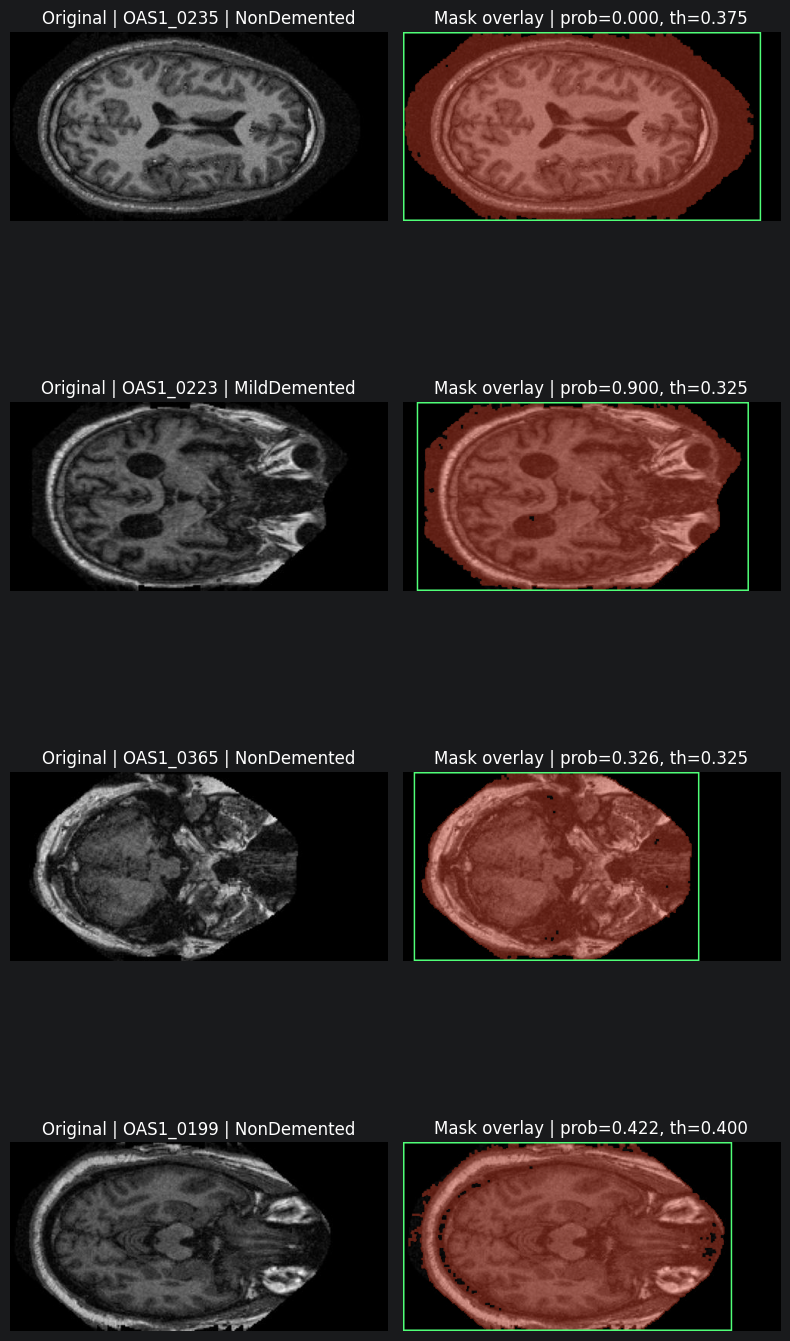

Preview saved: C:\Users\user\alzheimer\multifoundation_screening_assistant\demo_assets\demo_segmentation_preview.png


In [8]:
fig, axes = plt.subplots(
    len(demo_cases_with_assets),
    2,
    figsize=(8, 4 * len(demo_cases_with_assets)),
)
if len(demo_cases_with_assets) == 1:
    axes = np.asarray([axes])

for row_index, (_, row) in enumerate(demo_cases_with_assets.iterrows()):
    original = Image.open(row["representative_image_path"]).convert("RGB")
    overlay = Image.open(row["overlay_path"]).convert("RGB")

    axes[row_index, 0].imshow(original, cmap="gray")
    axes[row_index, 0].set_title(
        f"Original | {row['patient_id']} | {row['class_name']}"
    )
    axes[row_index, 0].axis("off")

    axes[row_index, 1].imshow(overlay)
    axes[row_index, 1].set_title(
        f"Mask overlay | prob={row['probability']:.3f}, th={row['threshold']:.3f}"
    )
    axes[row_index, 1].axis("off")

plt.tight_layout()
preview_path = ASSET_DIR / "demo_segmentation_preview.png"
plt.savefig(preview_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"Preview saved: {preview_path}")


## 7. LLM report 생성

LLM에 전달할 정보는 모델이 실제로 계산한 값으로 제한합니다.

LLM이 새 의학적 근거를 만들어내지 않도록 prompt에 다음 제한을 둡니다.

- mask는 병변 위치가 아니라 brain foreground 보조 정보라고 설명
- 확률, threshold, 예측 결과만 근거로 사용
- 진단 확정 표현 금지
- 추가 검사는 전문 의료진에게 의뢰해야 한다고 명시


In [9]:
SYSTEM_PROMPT = """
너는 의료 진단을 확정하는 의사가 아니다.
너의 역할은 이미 계산된 MRI screening 모델 결과를 사람이 읽기 쉬운 한국어 보고서로 정리하는 것이다.
모델이 제공하지 않은 의학적 소견을 새로 만들어내지 마라.
segmentation mask는 알츠하이머 병변 위치가 아니라 brain foreground 보조 시각화라고 설명하라.
최종 문장에는 이 결과가 진단이 아니라 연구용 screening 결과임을 분명히 적어라.
""".strip()


def model_decision_text(pred_label):
    return "비정상 의심" if int(pred_label) == 1 else "정상 가능성"


def confidence_band(probability, threshold):
    distance = abs(float(probability) - float(threshold))
    if distance < 0.05:
        return "threshold에 매우 가까운 경계 결과"
    if distance < 0.15:
        return "중간 정도의 확신"
    return "상대적으로 명확한 결과"


def build_case_payload(row):
    return {
        "patient_id": str(row["patient_id"]),
        "case_type": str(row["case_type"]),
        "experimental_ground_truth_class": str(row["class_name"]),
        "model": "BiomedCLIP frozen image encoder + adapter probe",
        "task": "Stage 1 binary screening: NonDemented vs Demented",
        "probability_demented": round(float(row["probability"]), 4),
        "threshold": round(float(row["threshold"]), 4),
        "prediction": model_decision_text(row["pred_label"]),
        "confidence_band": confidence_band(row["probability"], row["threshold"]),
        "segmentation_method": str(row["segmentation_method"]),
        "mask_interpretation": (
            "brain foreground 보조 mask이며, 알츠하이머 병변 위치나 "
            "해부학적 ROI annotation이 아님"
        ),
        "overlay_path": str(row["overlay_path"]),
        "crop_path": str(row["crop_path"]),
    }


def build_llm_prompt(payload):
    return f"""
아래 JSON은 Alzheimer MRI screening assistant의 한 환자 예시 결과다.
이 정보를 바탕으로 한국어 보고서를 작성하라.

작성 형식:
1. 입력 요약
2. 모델 판단
3. segmentation 결과의 의미
4. 해석상 주의점
5. 후속 확인 권고

제약:
- diagnosis, 확진, 병변 위치 검출 같은 표현을 쓰지 말 것
- ground truth class는 실험 검증용 metadata로만 언급할 것
- MRI에서 관찰되지 않은 의학적 소견을 생성하지 말 것

JSON:
{json.dumps(payload, ensure_ascii=False, indent=2)}
""".strip()


def generate_template_report(payload):
    probability = payload["probability_demented"]
    threshold = payload["threshold"]
    prediction = payload["prediction"]
    confidence = payload["confidence_band"]

    report = f"""
### {payload['patient_id']} screening report

1. 입력 요약
- 입력 영상은 Alzheimer MRI 연구 데이터의 대표 slice입니다.
- segmentation 단계에서는 뇌 foreground 후보 영역을 분리해 overlay와 crop 이미지를 생성했습니다.
- 사용한 segmentation 방식: {payload['segmentation_method']}

2. 모델 판단
- 사용 모델: {payload['model']}
- 과제 정의: {payload['task']}
- 비정상 class 확률: {probability:.4f}
- 적용 threshold: {threshold:.4f}
- 최종 screening 판단: {prediction}
- 확신 수준: {confidence}

3. segmentation 결과의 의미
- 생성된 mask는 뇌 영역을 보기 쉽게 정리하기 위한 보조 정보입니다.
- 이 mask는 알츠하이머 병변 위치, hippocampus 위축 영역, 또는 의학적 ROI annotation을 의미하지 않습니다.

4. 해석상 주의점
- 이 결과는 환자 단위 cross-validation 실험에서 나온 연구용 screening 출력입니다.
- 모델은 MRI 이미지 패턴과 학습된 feature를 기반으로 확률을 계산하지만, 임상 진단을 대체할 수 없습니다.
- threshold 근처의 결과는 작은 변화에도 판단이 바뀔 수 있으므로 특히 보수적으로 해석해야 합니다.

5. 후속 확인 권고
- 실제 임상 판단에는 전문의 판독, 임상 증상, 인지검사, 추가 영상검사 등이 함께 필요합니다.
- 본 보고서는 연구 프로젝트의 foundation model pipeline 데모 결과로만 사용해야 합니다.
""".strip()
    return report


def call_openai_compatible_llm(prompt, timeout=90):
    import requests

    url = LLM_API_BASE.rstrip("/") + "/chat/completions"
    headers = {
        "Authorization": f"Bearer {LLM_API_KEY}",
        "Content-Type": "application/json",
    }
    body = {
        "model": LLM_MODEL,
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": prompt},
        ],
        "temperature": 0.2,
    }
    response = requests.post(url, headers=headers, json=body, timeout=timeout)
    response.raise_for_status()
    data = response.json()
    return data["choices"][0]["message"]["content"]


def generate_report(payload):
    prompt = build_llm_prompt(payload)

    if LLM_BACKEND == "openai_compatible":
        try:
            return call_openai_compatible_llm(prompt), prompt, "openai_compatible"
        except Exception as exc:
            print(f"LLM 호출 실패. template report로 대체합니다: {exc}")

    return generate_template_report(payload), prompt, "template"


In [10]:
report_records = []

for _, row in demo_cases_with_assets.iterrows():
    payload = build_case_payload(row)
    report, prompt, report_backend = generate_report(payload)

    safe_id = re.sub(r"[^A-Za-z0-9_]+", "_", payload["patient_id"])
    report_path = REPORT_DIR / f"{safe_id}_screening_report.md"
    prompt_path = REPORT_DIR / f"{safe_id}_llm_prompt.md"
    report_path.write_text(report, encoding="utf-8")
    prompt_path.write_text(prompt, encoding="utf-8")

    report_records.append({
        **payload,
        "report_backend": report_backend,
        "report_path": str(report_path),
        "prompt_path": str(prompt_path),
    })

report_df = pd.DataFrame(report_records)
report_csv_path = OUTPUT_DIR / "demo_case_report_index.csv"
report_df.to_csv(report_csv_path, index=False, encoding="utf-8-sig")

display(
    report_df[
        [
            "patient_id",
            "case_type",
            "prediction",
            "probability_demented",
            "threshold",
            "report_backend",
            "report_path",
        ]
    ]
)

print(f"Report index saved: {report_csv_path}")


,patient_id,case_type,prediction,probability_demented,threshold,report_backend,report_path
0,OAS1_0235,정상으로 맞힌 낮은 위험도 사례,정상 가능성,0.0000,0.375,template,C:\Users\user\alzheimer\multifoundation_screen...
1,OAS1_0223,비정상으로 맞힌 높은 위험도 사례,비정상 의심,0.9003,0.325,template,C:\Users\user\alzheimer\multifoundation_screen...
2,OAS1_0365,threshold 근처의 경계 사례,비정상 의심,0.3265,0.325,template,C:\Users\user\alzheimer\multifoundation_screen...
3,OAS1_0199,오분류 사례,비정상 의심,0.4215,0.400,template,C:\Users\user\alzheimer\multifoundation_screen...


Report index saved: C:\Users\user\alzheimer\multifoundation_screening_assistant\demo_case_report_index.csv


In [11]:
for _, row in report_df.iterrows():
    display(Markdown(Path(row["report_path"]).read_text(encoding="utf-8")))


### OAS1_0235 screening report

1. 입력 요약
- 입력 영상은 Alzheimer MRI 연구 데이터의 대표 slice입니다.
- segmentation 단계에서는 뇌 foreground 후보 영역을 분리해 overlay와 crop 이미지를 생성했습니다.
- 사용한 segmentation 방식: automatic_foreground_fallback (SAM_CHECKPOINT가 지정되지 않았습니다.)

2. 모델 판단
- 사용 모델: BiomedCLIP frozen image encoder + adapter probe
- 과제 정의: Stage 1 binary screening: NonDemented vs Demented
- 비정상 class 확률: 0.0000
- 적용 threshold: 0.3750
- 최종 screening 판단: 정상 가능성
- 확신 수준: 상대적으로 명확한 결과

3. segmentation 결과의 의미
- 생성된 mask는 뇌 영역을 보기 쉽게 정리하기 위한 보조 정보입니다.
- 이 mask는 알츠하이머 병변 위치, hippocampus 위축 영역, 또는 의학적 ROI annotation을 의미하지 않습니다.

4. 해석상 주의점
- 이 결과는 환자 단위 cross-validation 실험에서 나온 연구용 screening 출력입니다.
- 모델은 MRI 이미지 패턴과 학습된 feature를 기반으로 확률을 계산하지만, 임상 진단을 대체할 수 없습니다.
- threshold 근처의 결과는 작은 변화에도 판단이 바뀔 수 있으므로 특히 보수적으로 해석해야 합니다.

5. 후속 확인 권고
- 실제 임상 판단에는 전문의 판독, 임상 증상, 인지검사, 추가 영상검사 등이 함께 필요합니다.
- 본 보고서는 연구 프로젝트의 foundation model pipeline 데모 결과로만 사용해야 합니다.

### OAS1_0223 screening report

1. 입력 요약
- 입력 영상은 Alzheimer MRI 연구 데이터의 대표 slice입니다.
- segmentation 단계에서는 뇌 foreground 후보 영역을 분리해 overlay와 crop 이미지를 생성했습니다.
- 사용한 segmentation 방식: automatic_foreground_fallback (SAM_CHECKPOINT가 지정되지 않았습니다.)

2. 모델 판단
- 사용 모델: BiomedCLIP frozen image encoder + adapter probe
- 과제 정의: Stage 1 binary screening: NonDemented vs Demented
- 비정상 class 확률: 0.9003
- 적용 threshold: 0.3250
- 최종 screening 판단: 비정상 의심
- 확신 수준: 상대적으로 명확한 결과

3. segmentation 결과의 의미
- 생성된 mask는 뇌 영역을 보기 쉽게 정리하기 위한 보조 정보입니다.
- 이 mask는 알츠하이머 병변 위치, hippocampus 위축 영역, 또는 의학적 ROI annotation을 의미하지 않습니다.

4. 해석상 주의점
- 이 결과는 환자 단위 cross-validation 실험에서 나온 연구용 screening 출력입니다.
- 모델은 MRI 이미지 패턴과 학습된 feature를 기반으로 확률을 계산하지만, 임상 진단을 대체할 수 없습니다.
- threshold 근처의 결과는 작은 변화에도 판단이 바뀔 수 있으므로 특히 보수적으로 해석해야 합니다.

5. 후속 확인 권고
- 실제 임상 판단에는 전문의 판독, 임상 증상, 인지검사, 추가 영상검사 등이 함께 필요합니다.
- 본 보고서는 연구 프로젝트의 foundation model pipeline 데모 결과로만 사용해야 합니다.

### OAS1_0365 screening report

1. 입력 요약
- 입력 영상은 Alzheimer MRI 연구 데이터의 대표 slice입니다.
- segmentation 단계에서는 뇌 foreground 후보 영역을 분리해 overlay와 crop 이미지를 생성했습니다.
- 사용한 segmentation 방식: automatic_foreground_fallback (SAM_CHECKPOINT가 지정되지 않았습니다.)

2. 모델 판단
- 사용 모델: BiomedCLIP frozen image encoder + adapter probe
- 과제 정의: Stage 1 binary screening: NonDemented vs Demented
- 비정상 class 확률: 0.3265
- 적용 threshold: 0.3250
- 최종 screening 판단: 비정상 의심
- 확신 수준: threshold에 매우 가까운 경계 결과

3. segmentation 결과의 의미
- 생성된 mask는 뇌 영역을 보기 쉽게 정리하기 위한 보조 정보입니다.
- 이 mask는 알츠하이머 병변 위치, hippocampus 위축 영역, 또는 의학적 ROI annotation을 의미하지 않습니다.

4. 해석상 주의점
- 이 결과는 환자 단위 cross-validation 실험에서 나온 연구용 screening 출력입니다.
- 모델은 MRI 이미지 패턴과 학습된 feature를 기반으로 확률을 계산하지만, 임상 진단을 대체할 수 없습니다.
- threshold 근처의 결과는 작은 변화에도 판단이 바뀔 수 있으므로 특히 보수적으로 해석해야 합니다.

5. 후속 확인 권고
- 실제 임상 판단에는 전문의 판독, 임상 증상, 인지검사, 추가 영상검사 등이 함께 필요합니다.
- 본 보고서는 연구 프로젝트의 foundation model pipeline 데모 결과로만 사용해야 합니다.

### OAS1_0199 screening report

1. 입력 요약
- 입력 영상은 Alzheimer MRI 연구 데이터의 대표 slice입니다.
- segmentation 단계에서는 뇌 foreground 후보 영역을 분리해 overlay와 crop 이미지를 생성했습니다.
- 사용한 segmentation 방식: automatic_foreground_fallback (SAM_CHECKPOINT가 지정되지 않았습니다.)

2. 모델 판단
- 사용 모델: BiomedCLIP frozen image encoder + adapter probe
- 과제 정의: Stage 1 binary screening: NonDemented vs Demented
- 비정상 class 확률: 0.4215
- 적용 threshold: 0.4000
- 최종 screening 판단: 비정상 의심
- 확신 수준: threshold에 매우 가까운 경계 결과

3. segmentation 결과의 의미
- 생성된 mask는 뇌 영역을 보기 쉽게 정리하기 위한 보조 정보입니다.
- 이 mask는 알츠하이머 병변 위치, hippocampus 위축 영역, 또는 의학적 ROI annotation을 의미하지 않습니다.

4. 해석상 주의점
- 이 결과는 환자 단위 cross-validation 실험에서 나온 연구용 screening 출력입니다.
- 모델은 MRI 이미지 패턴과 학습된 feature를 기반으로 확률을 계산하지만, 임상 진단을 대체할 수 없습니다.
- threshold 근처의 결과는 작은 변화에도 판단이 바뀔 수 있으므로 특히 보수적으로 해석해야 합니다.

5. 후속 확인 권고
- 실제 임상 판단에는 전문의 판독, 임상 증상, 인지검사, 추가 영상검사 등이 함께 필요합니다.
- 본 보고서는 연구 프로젝트의 foundation model pipeline 데모 결과로만 사용해야 합니다.

## 8. 발표에 넣을 핵심 설명

아래 문장을 그대로 발표 자료에 옮겨도 됩니다.


In [12]:
presentation_text = f"""
# Multi-Foundation Alzheimer MRI Screening Assistant

본 프로젝트는 Alzheimer MRI 이미지를 단순히 한 모델로 분류하는 데서 끝내지 않고,
여러 foundation model의 역할을 분리해 연결하는 screening assistant 형태로 확장했다.

1. Segmentation module
- MRI 이미지에서 검은 배경을 제외한 brain foreground 후보 영역을 분리한다.
- 이 mask는 병변 위치가 아니라 입력 정제와 시각화 보조를 위한 영역이다.
- SAM/MedSAM checkpoint가 있으면 box prompt 기반 segmentation을 사용할 수 있고,
  없을 경우 자동 foreground fallback을 사용한다.

2. BiomedCLIP adapter classifier
- 기존 ver11 실험에서 가장 안정적이었던 frozen BiomedCLIP encoder + adapter probe를 사용한다.
- 환자 단위 5-fold split을 유지해 data leakage를 방지했다.
- 현재 OOF 성능:
  sensitivity={oof_metrics['sensitivity']:.3f},
  specificity={oof_metrics['specificity']:.3f},
  F1={oof_metrics['f1']:.3f},
  AUROC={oof_metrics['auroc']:.3f},
  AUPRC={oof_metrics['auprc']:.3f}.

3. LLM report module
- 분류 확률, threshold, segmentation 설명, 주의사항을 구조화된 prompt로 전달한다.
- LLM은 새로운 의학적 소견을 생성하지 않고, 연구용 screening 결과를 사람이 읽기 쉬운 보고서로 변환한다.

최종적으로 이 구조는 MRI -> segmentation -> BiomedCLIP classification -> LLM report로 이어지는
multi-foundation model pipeline을 보여준다.
""".strip()

presentation_text_path = OUTPUT_DIR / "presentation_text_multifoundation_pipeline.md"
presentation_text_path.write_text(presentation_text, encoding="utf-8")

display(Markdown(presentation_text))
print(f"Saved: {presentation_text_path}")


# Multi-Foundation Alzheimer MRI Screening Assistant

본 프로젝트는 Alzheimer MRI 이미지를 단순히 한 모델로 분류하는 데서 끝내지 않고,
여러 foundation model의 역할을 분리해 연결하는 screening assistant 형태로 확장했다.

1. Segmentation module
- MRI 이미지에서 검은 배경을 제외한 brain foreground 후보 영역을 분리한다.
- 이 mask는 병변 위치가 아니라 입력 정제와 시각화 보조를 위한 영역이다.
- SAM/MedSAM checkpoint가 있으면 box prompt 기반 segmentation을 사용할 수 있고,
  없을 경우 자동 foreground fallback을 사용한다.

2. BiomedCLIP adapter classifier
- 기존 ver11 실험에서 가장 안정적이었던 frozen BiomedCLIP encoder + adapter probe를 사용한다.
- 환자 단위 5-fold split을 유지해 data leakage를 방지했다.
- 현재 OOF 성능:
  sensitivity=0.889,
  specificity=0.823,
  F1=0.720,
  AUROC=0.899,
  AUPRC=0.665.

3. LLM report module
- 분류 확률, threshold, segmentation 설명, 주의사항을 구조화된 prompt로 전달한다.
- LLM은 새로운 의학적 소견을 생성하지 않고, 연구용 screening 결과를 사람이 읽기 쉬운 보고서로 변환한다.

최종적으로 이 구조는 MRI -> segmentation -> BiomedCLIP classification -> LLM report로 이어지는
multi-foundation model pipeline을 보여준다.

Saved: C:\Users\user\alzheimer\multifoundation_screening_assistant\presentation_text_multifoundation_pipeline.md


## 9. 다음 확장 방향

시간이 남으면 다음 비교를 추가할 수 있습니다.

1. 원본 이미지 입력 vs brain crop 입력의 BiomedCLIP feature cache 성능 비교
2. SAM/MedSAM checkpoint를 실제로 연결한 segmentation 결과와 fallback mask 비교
3. LLM backend를 로컬 모델 또는 API 모델로 바꿔 같은 structured prompt에 대한 보고서 품질 비교

다만 현 단계의 핵심 결론은 성능 향상보다 전체 pipeline 구성입니다. 즉, segmentation은 진단 병변 탐지가 아니라 brain foreground 시각화 보조이며, LLM은 진단 생성이 아니라 모델 결과 설명 생성입니다.
